# ⚡ Online Machine Learning (Incremental Learning)

> *A training approach where the model keeps learning piece by piece as new data arrives — like a student who reviews and updates their notes a little every single day, instead of cramming once a semester.*

## 🎯 In One Line

**Online Learning** (also called **Incremental Learning**) trains a model **sequentially, in small batches or one instance at a time**, instead of all at once. After each small batch, the model **improves a little** — and this can keep happening even after the model is already live in production.

This is the opposite of **Batch (Offline) Learning**, where the model is fully retrained from scratch on the whole dataset each cycle.

> 💡 **Simple analogy:** Many companies advertise that "the more you use our product, the better it performs." That's usually a sign they're using online learning — their model on the server keeps training with fresh data as people use the product, rather than being trained once and left untouched.

## ⚙️ How It Works

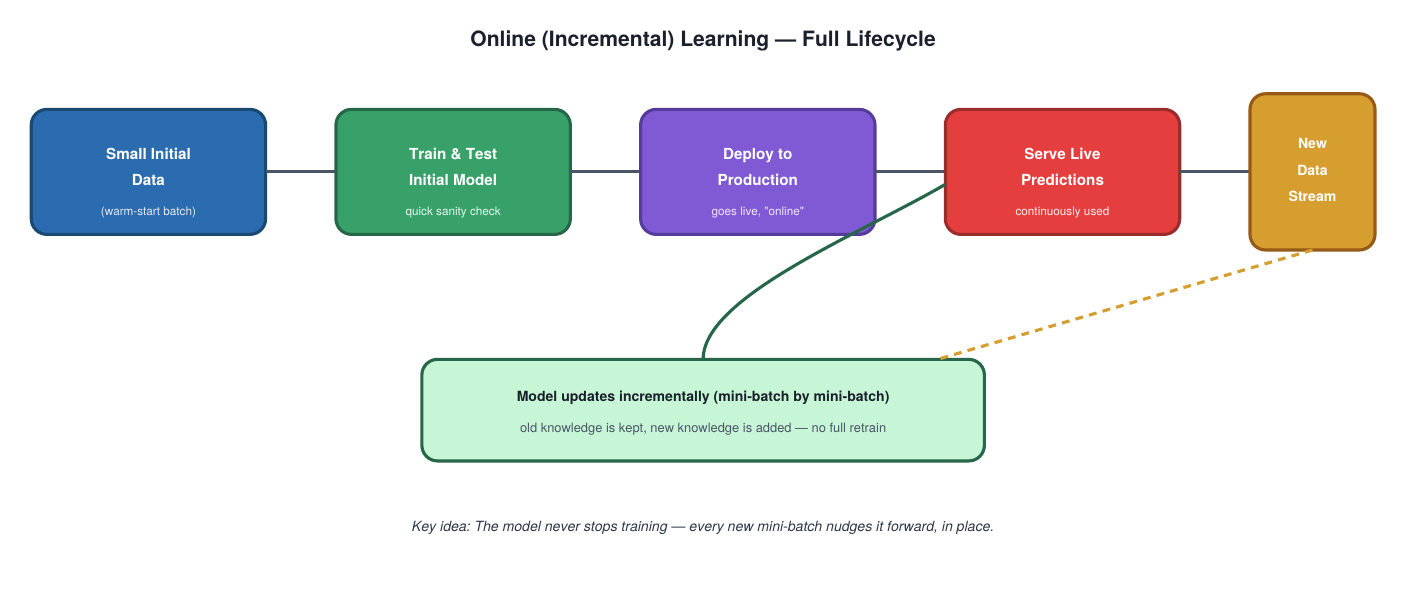

| Step | What Happens |
|---|---|
| ① **Small Initial Data** | Training starts with a small amount of data (a "warm start") |
| ② **Train & Test** | The model is trained on this small batch and quickly sanity-checked |
| ③ **Deploy to Production** | The model goes live — this is the point it becomes "online" |
| ④ **Serve Live Predictions** | The model continuously makes predictions for real users/requests |
| ⑤ **New Data Stream** | Fresh data keeps arriving continuously (clicks, transactions, sensor readings, etc.) |
| ⑥ **Incremental Update** | The model updates itself mini-batch by mini-batch — old knowledge is kept, new patterns are absorbed, with **no full retrain from scratch** |

Unlike batch learning, if you want to "reset" an online model, you must explicitly discard it and start again — by default, it just keeps improving continuously as long as it's running.

## 🧬 Characteristics

| Characteristic | Explanation |
|---|---|
| 🔄 **Adaptability** | The model adjusts itself to new data patterns over time |
| ⏱️ **Real-Time Processing** | Well suited to streaming or live data |
| 💾 **Low Memory Consumption** | No need to hold the entire dataset in memory at once — data is processed in small pieces |
| 📈 **Continuous Improvement** | Performance can keep improving simply from more usage/more data flowing in |

## 🎚️ Why the Learning Rate Matters

In online learning, the **learning rate** controls *how aggressively* the model updates itself with each new mini-batch.

- **Learning rate too high** → the model changes very fast and can suffer from *catastrophic forgetting* — it forgets older patterns too quickly while chasing the newest data.
- **Learning rate too low** → the model adapts too slowly and may fail to keep up with real changes in the data.

> 🎯 **The goal:** find a learning rate where the model **remembers old patterns** while still being able to **learn new ones** — this balance is one of the trickiest parts of running online learning in production.

## 🗄️ Bonus Concept: Out-of-Core Learning

Sometimes a dataset is simply **too large to fit in memory** at once — for example, a 50 GB dataset on a machine with only 8 GB of RAM.

The solution is to reuse the *incremental training mechanism* from online learning, even though the underlying problem isn't changing over time:

1. Split the huge dataset into smaller chunks that **do** fit in memory.
2. Feed the chunks to the model **one at a time**, training incrementally on each.
3. Repeat until the entire dataset has been processed.

This is called **Out-of-Core Learning** — technically all the training can happen offline, but it *borrows* the same incremental-update technique used in true online learning.

## ⚖️ Batch Learning vs Online Learning

| Feature | 📦 Batch Learning | ⚡ Online Learning |
|---|---|---|
| Complexity | Simple — train once on your machine, deploy, predict | More complex — needs continuous monitoring in production |
| Computation power | High burst at training time, then idle | Continuous but typically lower per-step cost |
| Model updates | Requires a full manual retrain-and-redeploy cycle | Updates automatically as new data streams in |
| Best suited for | Problems that don't change much over time (e.g. classifying cats vs dogs) | Problems where the underlying pattern shifts quickly (e.g. stock prices, fast-changing customer behavior) |
| Tooling maturity | Very mature, standard ML tooling | Newer, fewer enterprise-grade tools (e.g. River, Vowpal Wabbit) |
| Cost at scale | Can get expensive to retrain huge models repeatedly | Often cheaper — small, frequent updates instead of full retrains |

## ✅ Advantages

| # | Advantage |
|---|---|
| 1 | **Real-Time Learning** — the model keeps updating as new data arrives |
| 2 | **Suitable for Large / Streaming Datasets** — works well when data is too big or arrives continuously |
| 3 | **Low Computational Cost per Step** — no need to reprocess the entire dataset at once |
| 4 | **Cost-Effective at Scale** — cheaper than repeatedly retraining a large batch model from scratch |

## ❌ Disadvantages

| # | Disadvantage |
|---|---|
| 1 | **Added Complexity** — the model must be retrained continuously as new data streams in |
| 2 | **Overfitting / Forgetting Risk** — balancing old vs. new data is tricky (see learning rate above) |
| 3 | **Requires Continuous Monitoring** — the model must be watched constantly to make sure it's behaving correctly |
| 4 | **Sensitive to Bad Data** — if corrupted or malicious data flows in (e.g. a hacked server sending garbage requests), the model can quickly become biased or broken |
| 5 | **Fewer Enterprise-Grade Tools** — the ecosystem is newer and less mature than batch-learning tooling |

## 🛡️ Managing the Risks

Because an online model's behavior is directly tied to whatever data is flowing in, a bad stretch of incoming data can quickly damage it. Two safeguards are essential in production:

1. **Active monitoring / anomaly detection** — continuously watch incoming data and model behavior; if anything looks abnormal, automatically pause updates or reject the suspicious data.
2. **A rollback plan** — always keep the ability to quickly switch traffic back to a previous, known-good version of the model if something goes wrong.

## 🌍 Real-World Examples

| Domain | Use Case |
|---|---|
| 💬 **Chatbots / Voice Assistants** | Google Now, Siri-style assistants improve responses using ongoing interactions |
| ⌨️ **Predictive Keyboards** | SwiftKey and similar keyboards adapt their word predictions dynamically as you type |
| 📺 **Video Recommendations** | YouTube's recommendation feed updates based on which videos you click on and watch |
| 📈 **Stock Market Prediction** | Market data changes rapidly, so predictions benefit from continuous model updates |
| 🏦 **Fraud Detection in Banking** | Bank transaction data is analyzed continuously to catch fraud as it happens |
| 📡 **Sensor / IoT Data Analysis** | Devices streaming continuous sensor data are natural candidates for online learning |

## 🐍 Python Example — Simulating a Streaming, Incremental Learning Pipeline

The code below uses scikit-learn's `SGDClassifier`, which supports `partial_fit()` — the key method that enables true incremental training. We simulate a live data stream arriving in small mini-batches, and the model updates itself after every single batch, without ever seeing the full dataset at once.

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import joblib
import time

# ------------------------------------------------------------------
# 1. Create a synthetic "stream" of data
# ------------------------------------------------------------------
X, y = make_classification(
    n_samples=5000, n_features=10, n_informative=6,
    n_redundant=2, random_state=42
)

# Hold out a fixed test set to track accuracy over time
X_pool, X_test, y_pool, y_test = X[:4500], X[4500:], y[:4500], y[4500:]

# Simulate the data arriving as a stream of small mini-batches
mini_batch_size = 50
n_batches = len(X_pool) // mini_batch_size

# ------------------------------------------------------------------
# 2. Online Learning simulation — the model updates incrementally,
#    one mini-batch at a time, using partial_fit()
# ------------------------------------------------------------------
model = SGDClassifier(loss="log_loss", learning_rate="optimal", random_state=42)
classes = np.unique(y)  # required by partial_fit on the very first call

accuracy_history = []
update_times = []

for i in range(n_batches):
    start = i * mini_batch_size
    end = start + mini_batch_size
    batch_X, batch_y = X_pool[start:end], y_pool[start:end]

    t0 = time.time()
    if i == 0:
        # First call must declare all possible classes
        model.partial_fit(batch_X, batch_y, classes=classes)
    else:
        # Every later call just nudges the existing model forward
        model.partial_fit(batch_X, batch_y)
    update_times.append(time.time() - t0)

    # Check accuracy on the held-out test set after each update
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracy_history.append(acc)

    if (i + 1) % 10 == 0 or i == 0:
        print(f"Mini-batch {i + 1:>2}/{n_batches} | "
              f"samples seen so far = {(i + 1) * mini_batch_size:>5} | "
              f"test accuracy = {acc:.4f} | "
              f"update time = {update_times[-1]*1000:.2f} ms")

# ------------------------------------------------------------------
# 3. Save the live model (it can keep being updated later!)
# ------------------------------------------------------------------
joblib.dump(model, "online_model_latest.pkl")
print(f"\nFinal accuracy after {n_batches} incremental updates: {accuracy_history[-1]:.4f}")
print(f"Average time per mini-batch update: {np.mean(update_times)*1000:.3f} ms")
print("Model saved as 'online_model_latest.pkl' — ready to keep learning from new data.")

Mini-batch  1/90 | samples seen so far =    50 | test accuracy = 0.7460 | update time = 3.57 ms
Mini-batch 10/90 | samples seen so far =   500 | test accuracy = 0.7540 | update time = 0.56 ms
Mini-batch 20/90 | samples seen so far =  1000 | test accuracy = 0.7800 | update time = 0.59 ms
Mini-batch 30/90 | samples seen so far =  1500 | test accuracy = 0.6560 | update time = 0.67 ms
Mini-batch 40/90 | samples seen so far =  2000 | test accuracy = 0.7380 | update time = 0.59 ms
Mini-batch 50/90 | samples seen so far =  2500 | test accuracy = 0.6800 | update time = 0.63 ms
Mini-batch 60/90 | samples seen so far =  3000 | test accuracy = 0.5220 | update time = 0.72 ms
Mini-batch 70/90 | samples seen so far =  3500 | test accuracy = 0.6000 | update time = 0.70 ms
Mini-batch 80/90 | samples seen so far =  4000 | test accuracy = 0.6960 | update time = 0.74 ms
Mini-batch 90/90 | samples seen so far =  4500 | test accuracy = 0.7500 | update time = 0.63 ms

Final accuracy after 90 incremental upd

### 📊 A Real Example of the Learning-Rate Risk

Look closely at the accuracy numbers above — they don't climb smoothly. They bounce around (e.g. dropping to ~0.52 around mini-batch 60 before recovering to 0.75 by the end). This is a live demonstration of exactly the risk described earlier: with the default learning rate, each new mini-batch can push the model's decision boundary quite hard, causing it to **temporarily forget** what it learned from earlier batches. In a real production system, this kind of instability is why online learning needs a carefully tuned learning rate and continuous monitoring — not just a one-time setup and forget.

### 🔍 Code Explanation

| Step | What's Happening |
|---|---|
| **Data generation** | `make_classification` creates a synthetic dataset; a fixed test set is held out to track progress |
| **Mini-batch stream** | The remaining data is split into small 50-sample mini-batches, simulating a live stream |
| **`partial_fit()`** | This is the core of online learning — it updates the *existing* model with just the new mini-batch, instead of retraining from scratch |
| **First-call `classes=`** | `partial_fit` needs to know all possible class labels on its very first call, since it hasn't seen the full dataset |
| **Per-batch evaluation** | Accuracy is checked on the same held-out test set after every update, so we can watch the model improve in real time |
| **Timing** | Each update takes a tiny fraction of a second — this is what makes online learning cheap to run continuously, unlike a full batch retrain |
| **Model persistence** | The model is saved with `joblib` — and critically, it can be loaded later and keep learning with `partial_fit()`, unlike a batch model that would need full retraining |

> 🧠 **Notice:** We never call `SGDClassifier()` again after the first mini-batch — the **same model object** keeps absorbing new data via `partial_fit()`. This incremental, in-place update is exactly what separates Online Learning from Batch Learning, where a brand-new model is built from scratch every retraining cycle.

## 🧠 Quick Revision Questions

1. What is the key scikit-learn method that enables true online/incremental learning?
2. Why does a learning rate that's too high cause "catastrophic forgetting"?
3. What is Out-of-Core Learning, and how does it borrow from online learning even for offline problems?
4. Name two safeguards you should put in place before running an online model in production.
5. Give three real-world examples where online learning is a natural fit, and explain why batch learning wouldn't work as well.